In [1]:
import tensorflow as tf
print(tf.__version__)


2.18.0


In [3]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers
import numpy as np



In [5]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize the images to the range 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Expand dimensions for channel
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),  # Explicitly define the input shape here
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [13]:
model.fit(x_train, y_train, epochs=10, validation_split=0.1)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7666 - loss: 0.6448 - val_accuracy: 0.8770 - val_loss: 0.3325
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8833 - loss: 0.3168 - val_accuracy: 0.8898 - val_loss: 0.2930
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9021 - loss: 0.2683 - val_accuracy: 0.9040 - val_loss: 0.2592
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9114 - loss: 0.2343 - val_accuracy: 0.9090 - val_loss: 0.2426
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9264 - loss: 0.2021 - val_accuracy: 0.9122 - val_loss: 0.2433
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9337 - loss: 0.1756 - val_accuracy: 0.9127 - val_loss: 0.2447
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9427 - loss: 0.1563 - val_accuracy: 0.9147 - val_loss: 0.2425
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9479 - loss: 0

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")


313/313 - 1s - 2ms/step - accuracy: 0.9083 - loss: 0.2894
Test accuracy: 0.90829998254776


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


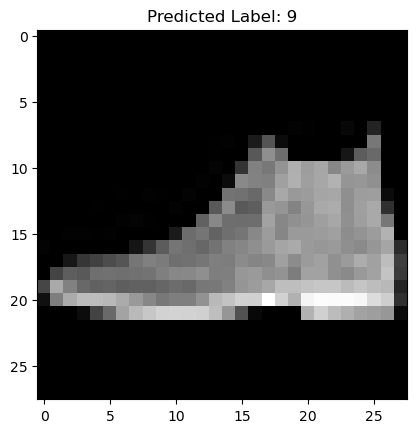

In [17]:
predictions = model.predict(x_test)

# Plot the first test image and its predicted label
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.title(f"Predicted Label: {np.argmax(predictions[0])}")
plt.show()


In [19]:
print(f"Predicted Label: {np.argmax(predictions[0])}")
print(f"Actual Label: {y_test[0]}")


Predicted Label: 9
Actual Label: 9


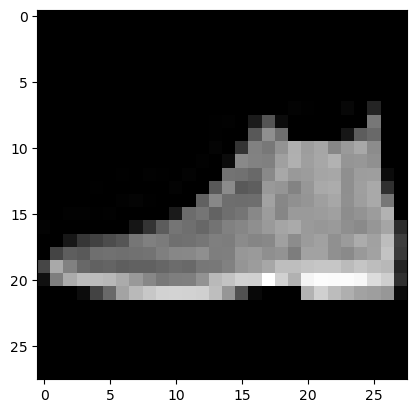

In [21]:
plt.imshow(x_test[0].squeeze(), cmap='gray', interpolation='nearest')


In [25]:
!pip install opencv-python


  Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl.metadata (20 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl (37.3 MB)


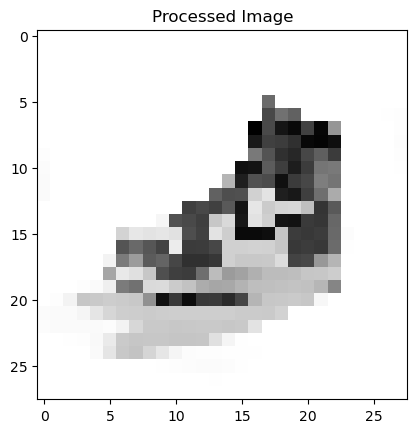

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path to your image (adjust based on location)
img_path = "datasets/sneaker.jpg"  

# Load in grayscale
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Resize to match Fashion MNIST (28x28)
img_resized = cv2.resize(img, (28, 28))

# Normalize pixel values (0 to 1)
img_resized = img_resized / 255.0

# Reshape for model input
img_resized = img_resized.reshape(1, 28, 28, 1)

# Display the processed image
plt.imshow(img_resized.squeeze(), cmap='gray')
plt.title("Processed Image")
plt.show()


In [37]:
# Predict class label
prediction = model.predict(img_resized)
predicted_label = np.argmax(prediction)

# Class labels from Fashion MNIST
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(f"Predicted Clothing Item: {class_names[predicted_label]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted Clothing Item: Bag


In [33]:
import os

img_path = "datasets/sneaker.png"  # Adjust if needed
print("Does file exist?", os.path.exists(img_path))


Does file exist? False
